In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features

2026-02-22 16:18:32.527 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9_loader = QM9Dataset()
qm9_loader.load()
frames = qm9_loader.run_stress_test()
frames_rotated = qm9_loader.run_stress_test(rotated=True)

2026-02-22 16:18:33.745 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-22 16:18:33.780 | INFO     | src.geometry:generate_stress_test:41 - Generating Grassmann Stress Test (Seed=40, Rotated=False)...
2026-02-22 16:18:33.799 | INFO     | src.geometry:generate_stress_test:99 - Generated 200 frames. Failed molecules: 0
2026-02-22 16:18:33.813 | SUCCESS  | src.geometry:generate_stress_test:103 - Saved stress test to data/QM9/stress_test.xyz
2026-02-22 16:18:33.814 | INFO     | src.geometry:generate_stress_test:41 - Generating Grassmann Stress Test (Seed=40, Rotated=True)...
2026-02-22 16:18:33.829 | INFO     | src.geometry:generate_stress_test:99 - Generated 200 frames. Failed molecules: 0
2026-02-22 16:18:33.841 | SUCCESS  | src.geometry:generate_stress_test:103 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [11]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 200 total frames.
[[-0.72099635  0.28430692  0.20531914]
 [-0.7190029  -0.99556299  0.41068636]
 [ 0.75365123 -1.20221233  0.45267405]
 [ 1.37972861 -0.11140072  0.13146266]
 [ 2.57040547  0.13015272  0.2599752 ]
 [ 0.1810873   0.8159788   0.19810483]
 [-1.66071138  0.46658381 -0.40454963]
 [ 0.27567765  2.00693052 -0.03892171]]
qm9_761
[H]c1noc(=O)n1[H]


In [12]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_761:
Max displacement: 0.4069 Å
Min displacement: 0.1749 Å
Average displacement: 0.2893 Å (Target was ~0.2)


In [13]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.2962 Å
Standard Deviation of bond length: 0.1651 Å


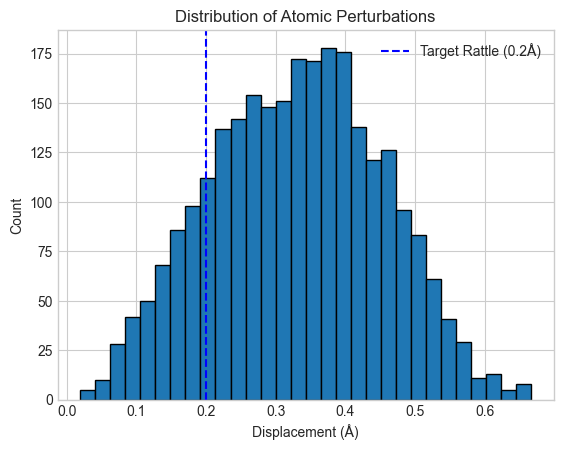

In [14]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Clustering

In [15]:
import polars as pl

def make_clustering(frames, processed=False):
    # --- 1. Generate Features ---
    print("Generating geometric features...")
    if processed:
        X = get_features_xyz(frames)
    else:
        X = get_raw_xyz_features(frames)
        
    print(f"Feature matrix shape: {X.shape}")

    # --- 2. Clustering (K-Means) ---
    unique_mol_ids = list(set([f.info['mol_id'] for f in frames]))
    n_clusters = len(unique_mol_ids)

    print(f"Clustering into {n_clusters} clusters (based on unique mol_ids found)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # --- 3. Evaluation ---
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info['smiles'] for f in frames]

    # Calculate Score
    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"Clustering Performance (Adjusted Rand Index): {ari_score:.4f}")

    # --- 4. Cluster Composition Table ---
    # We create a dataframe to easily group and see what went where
    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    # Summary: For each cluster, show which molecules it contains and how many
    # If ARI is 1.0, each cluster should only contain 1 unique mol_id
    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    print("\nCluster Composition Summary:")
    print(summary_table)

    # --- 5. Visualization (PCA) ---
    print("\nRunning PCA for visualization...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    expl_var = pca.explained_variance_ratio_

    # ---------- Styling for report quality ----------
    plt.style.use("seaborn-v0_8-whitegrid")  # clean academic style

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # Choose color palette depending on number of clusters
    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")

    # Scatter plot
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap=cmap,
        s=35,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_xlabel("PCA Component 1", fontsize=12)
    ax.set_ylabel("PCA Component 2", fontsize=12)

    title_prefix = "Processed (Invariant)" if processed else "Flattened (Raw)"
    ax.set_title(
        f"{title_prefix} XYZ Features — Clustering of Perturbed Geometries\n"
        f"Adjusted Rand Index = {ari_score:.3f}",
        fontsize=14,
        pad=12
    )

    # Cleaner legend
    legend = ax.legend(
        *scatter.legend_elements(num=n_clusters),
        title="Cluster ID",
        loc="best",
        frameon=True
    )
    ax.add_artist(legend)

    # Improve layout
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    fig.tight_layout()

    # Save high quality figure for report
    plt.savefig(f"report/qm9/figures/grassmann/pca_clustering_{processed}.png", dpi=300, bbox_inches="tight")

    plt.show()
    
    return summary_table

Generating geometric features...
Feature matrix shape: (200, 171)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 0.8341

Cluster Composition Summary:
shape: (10, 5)
┌─────────┬─────────────┬─────────────────────────┬────────────────────────────────┬───────────────┐
│ cluster ┆ unique_mols ┆ mol_ids_in_cluster      ┆ representative_smiles          ┆ total_samples │
│ ---     ┆ ---         ┆ ---                     ┆ ---                            ┆ ---           │
│ i32     ┆ u32         ┆ list[str]               ┆ str                            ┆ u32           │
╞═════════╪═════════════╪═════════════════════════╪════════════════════════════════╪═══════════════╡
│ 0       ┆ 1           ┆ ["qm9_761"]             ┆ [H]c1noc(=O)n1[H]              ┆ 20            │
│ 1       ┆ 1           ┆ ["qm9_639"]             ┆ [H]C1([H])O[C@]2([H])C([H])([H ┆ 20            │
│         ┆             ┆                         ┆ …             

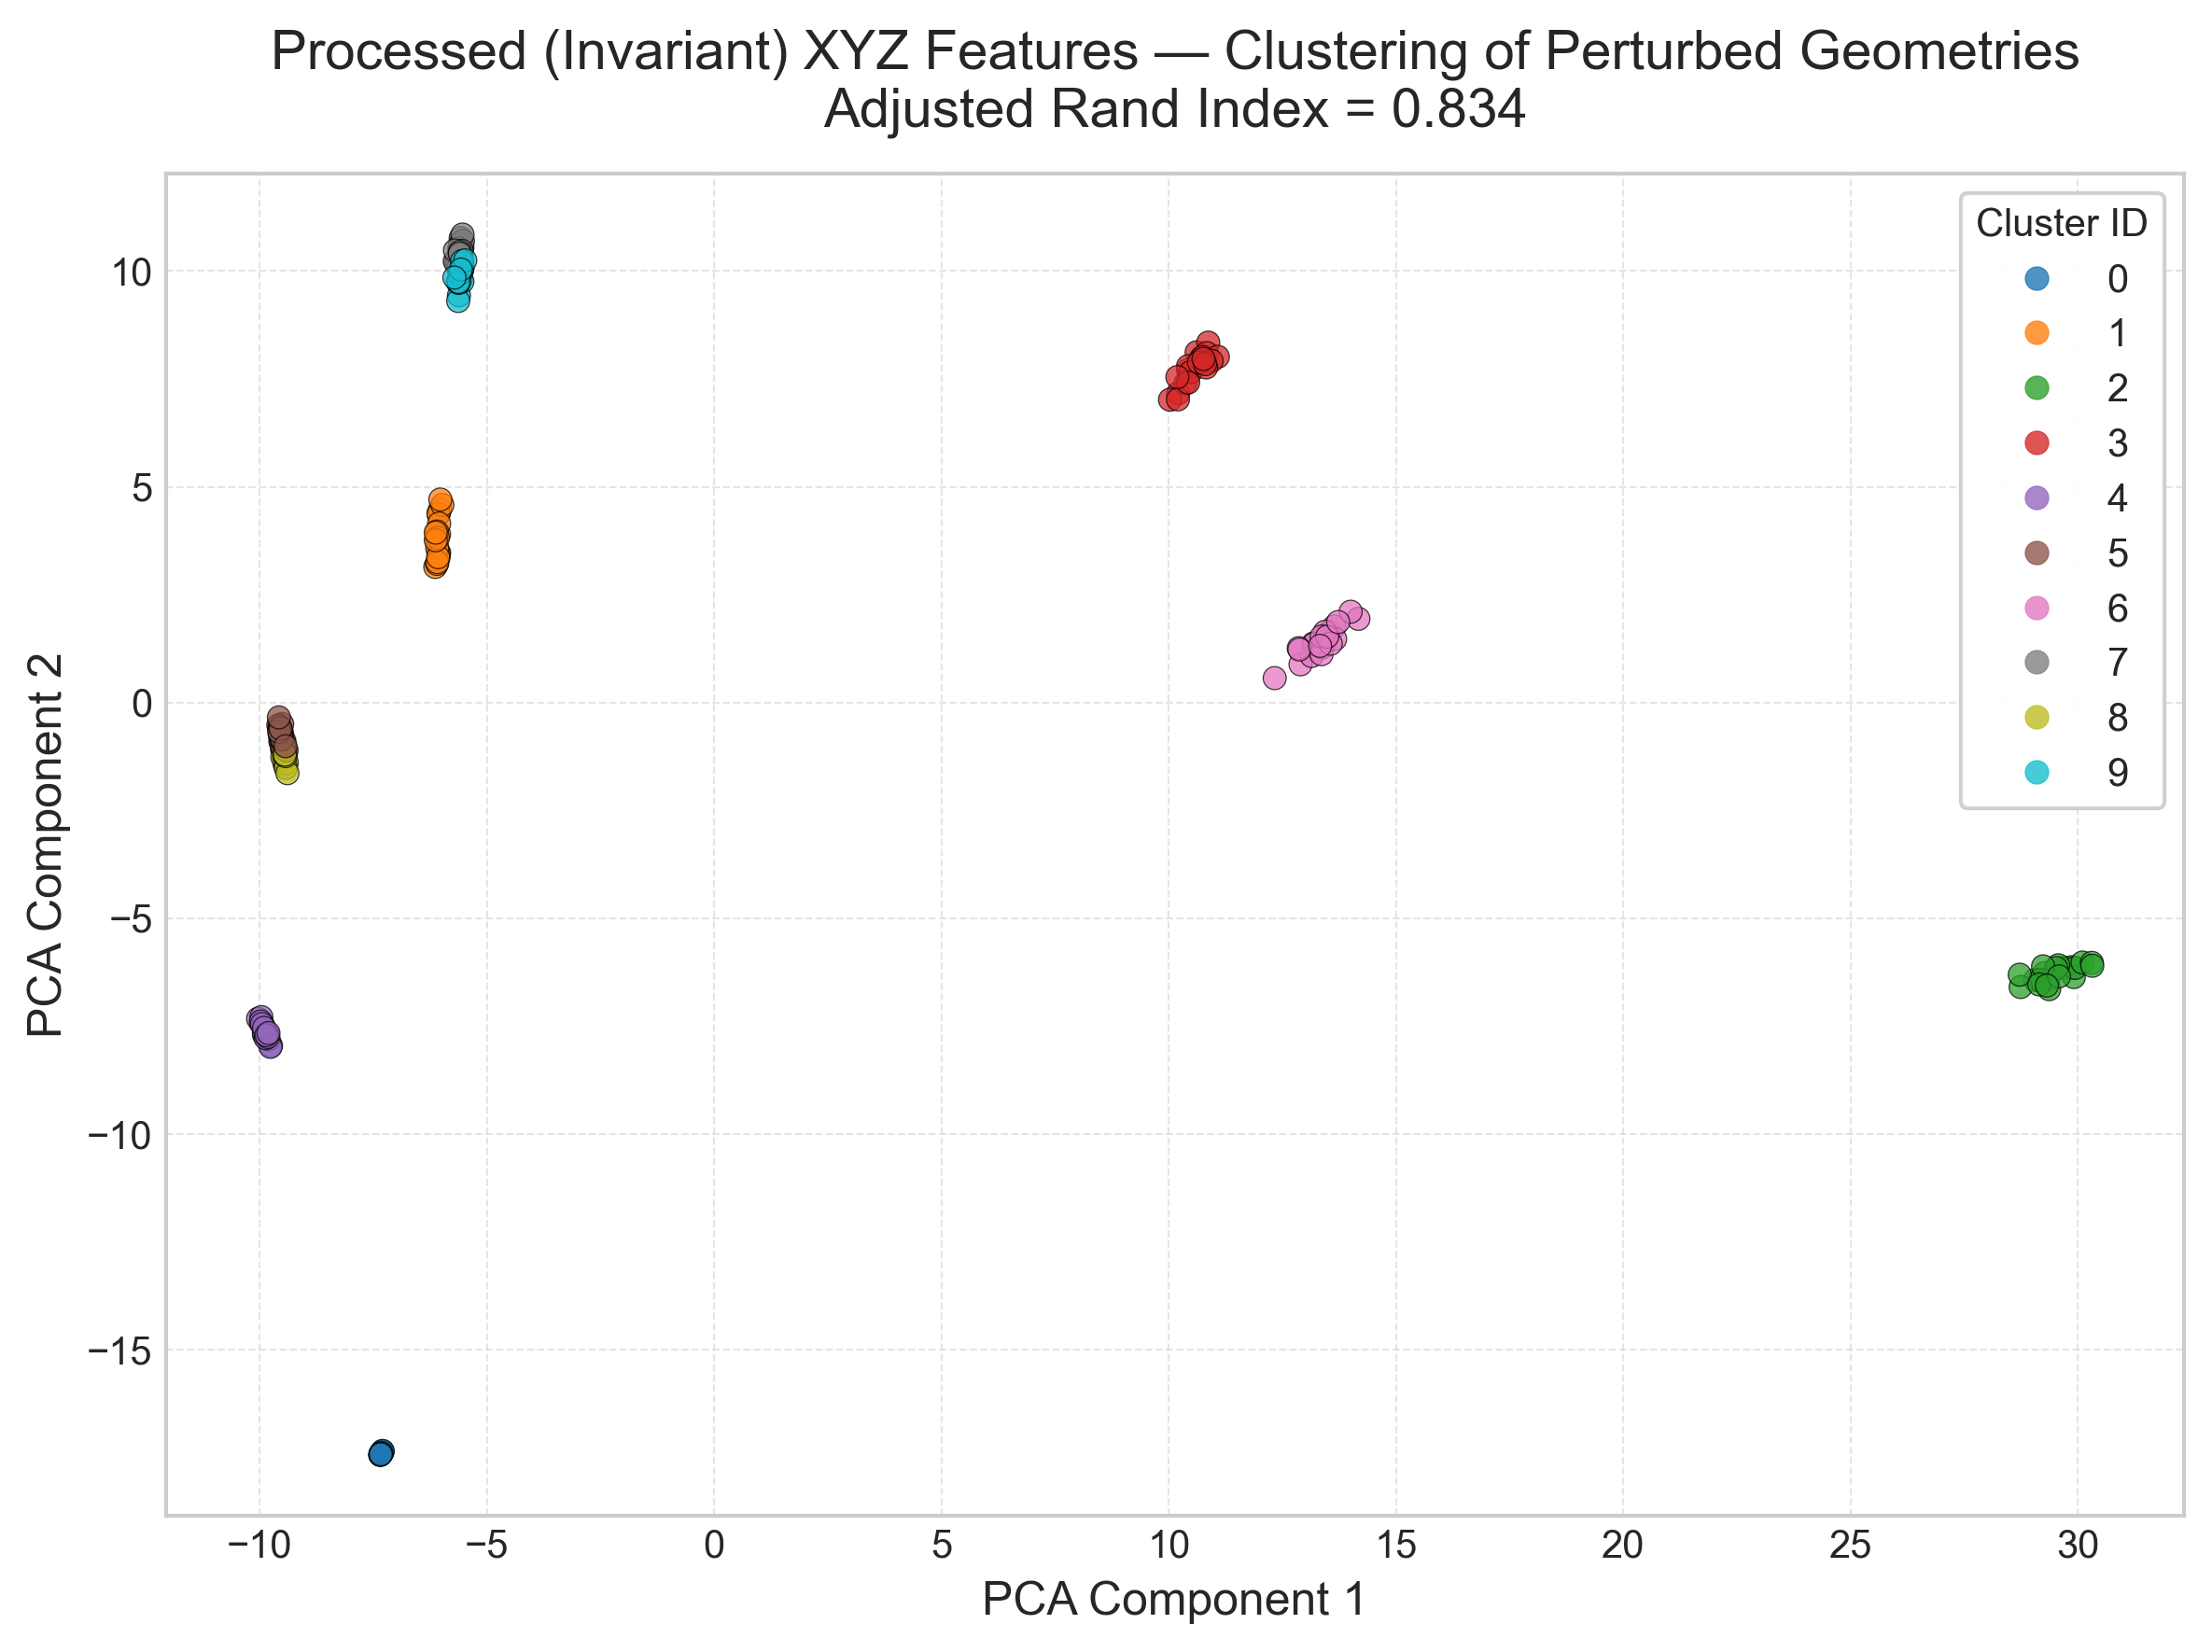

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_761""]","""[H]c1noc(=O)n1[H]""",20
1,1,"[""qm9_639""]","""[H]C1([H])O[C@]2([H])C([H])([H…",20
2,1,"[""qm9_1626""]","""[H]C([H])([H])C(=O)[C@]([H])(C…",20
3,1,"[""qm9_795""]","""[H]O/N=C(/C([H])([H])O[H])C([H…",20
4,1,"[""qm9_1026""]","""[H]c1nc(OC([H])([H])[H])oc1[H]""",20
5,2,"[""qm9_967"", ""qm9_779""]","""[H]c1oc([H])c(N([H])[H])c1N([H…",21
6,1,"[""qm9_1874""]","""[H]O[C@]12C([H])([H])C([H])([H…",20
7,2,"[""qm9_906"", ""qm9_1014""]","""[H]c1nc([H])c(C([H])([H])[H])c…",18
8,2,"[""qm9_967"", ""qm9_779""]","""[H]c1oc([H])c(N([H])[H])c1N([H…",19


In [24]:
make_clustering(frames, processed=True)

Generating geometric features...
flat list 1: [-0.72099635  0.28430692  0.20531914 -0.7190029  -0.99556299  0.41068636
  0.75365123 -1.20221233  0.45267405  1.37972861 -0.11140072  0.13146266
  2.57040547  0.13015272  0.2599752   0.1810873   0.8159788   0.19810483
 -1.66071138  0.46658381 -0.40454963  0.27567765  2.00693052 -0.03892171]
flat list 2: [-0.89588358  0.15342791 -0.08531049 -0.61157036 -1.03047708  0.08413914
  0.72511818 -1.11510744  0.30369947  1.18153771 -0.04619064  0.20920882
  2.36541316  0.2551453   0.58847408  0.09371443  1.01988547  0.05925844
 -1.96429133  0.5444466  -0.30895418  0.24439996  1.79816108 -0.02900337]
Feature matrix shape: (200, 57)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 1.0000

Cluster Composition Summary:
shape: (10, 5)
┌─────────┬─────────────┬────────────────────┬─────────────────────────────────┬───────────────┐
│ cluster ┆ unique_mols ┆ mol_ids_in_cluster ┆ representative_smi

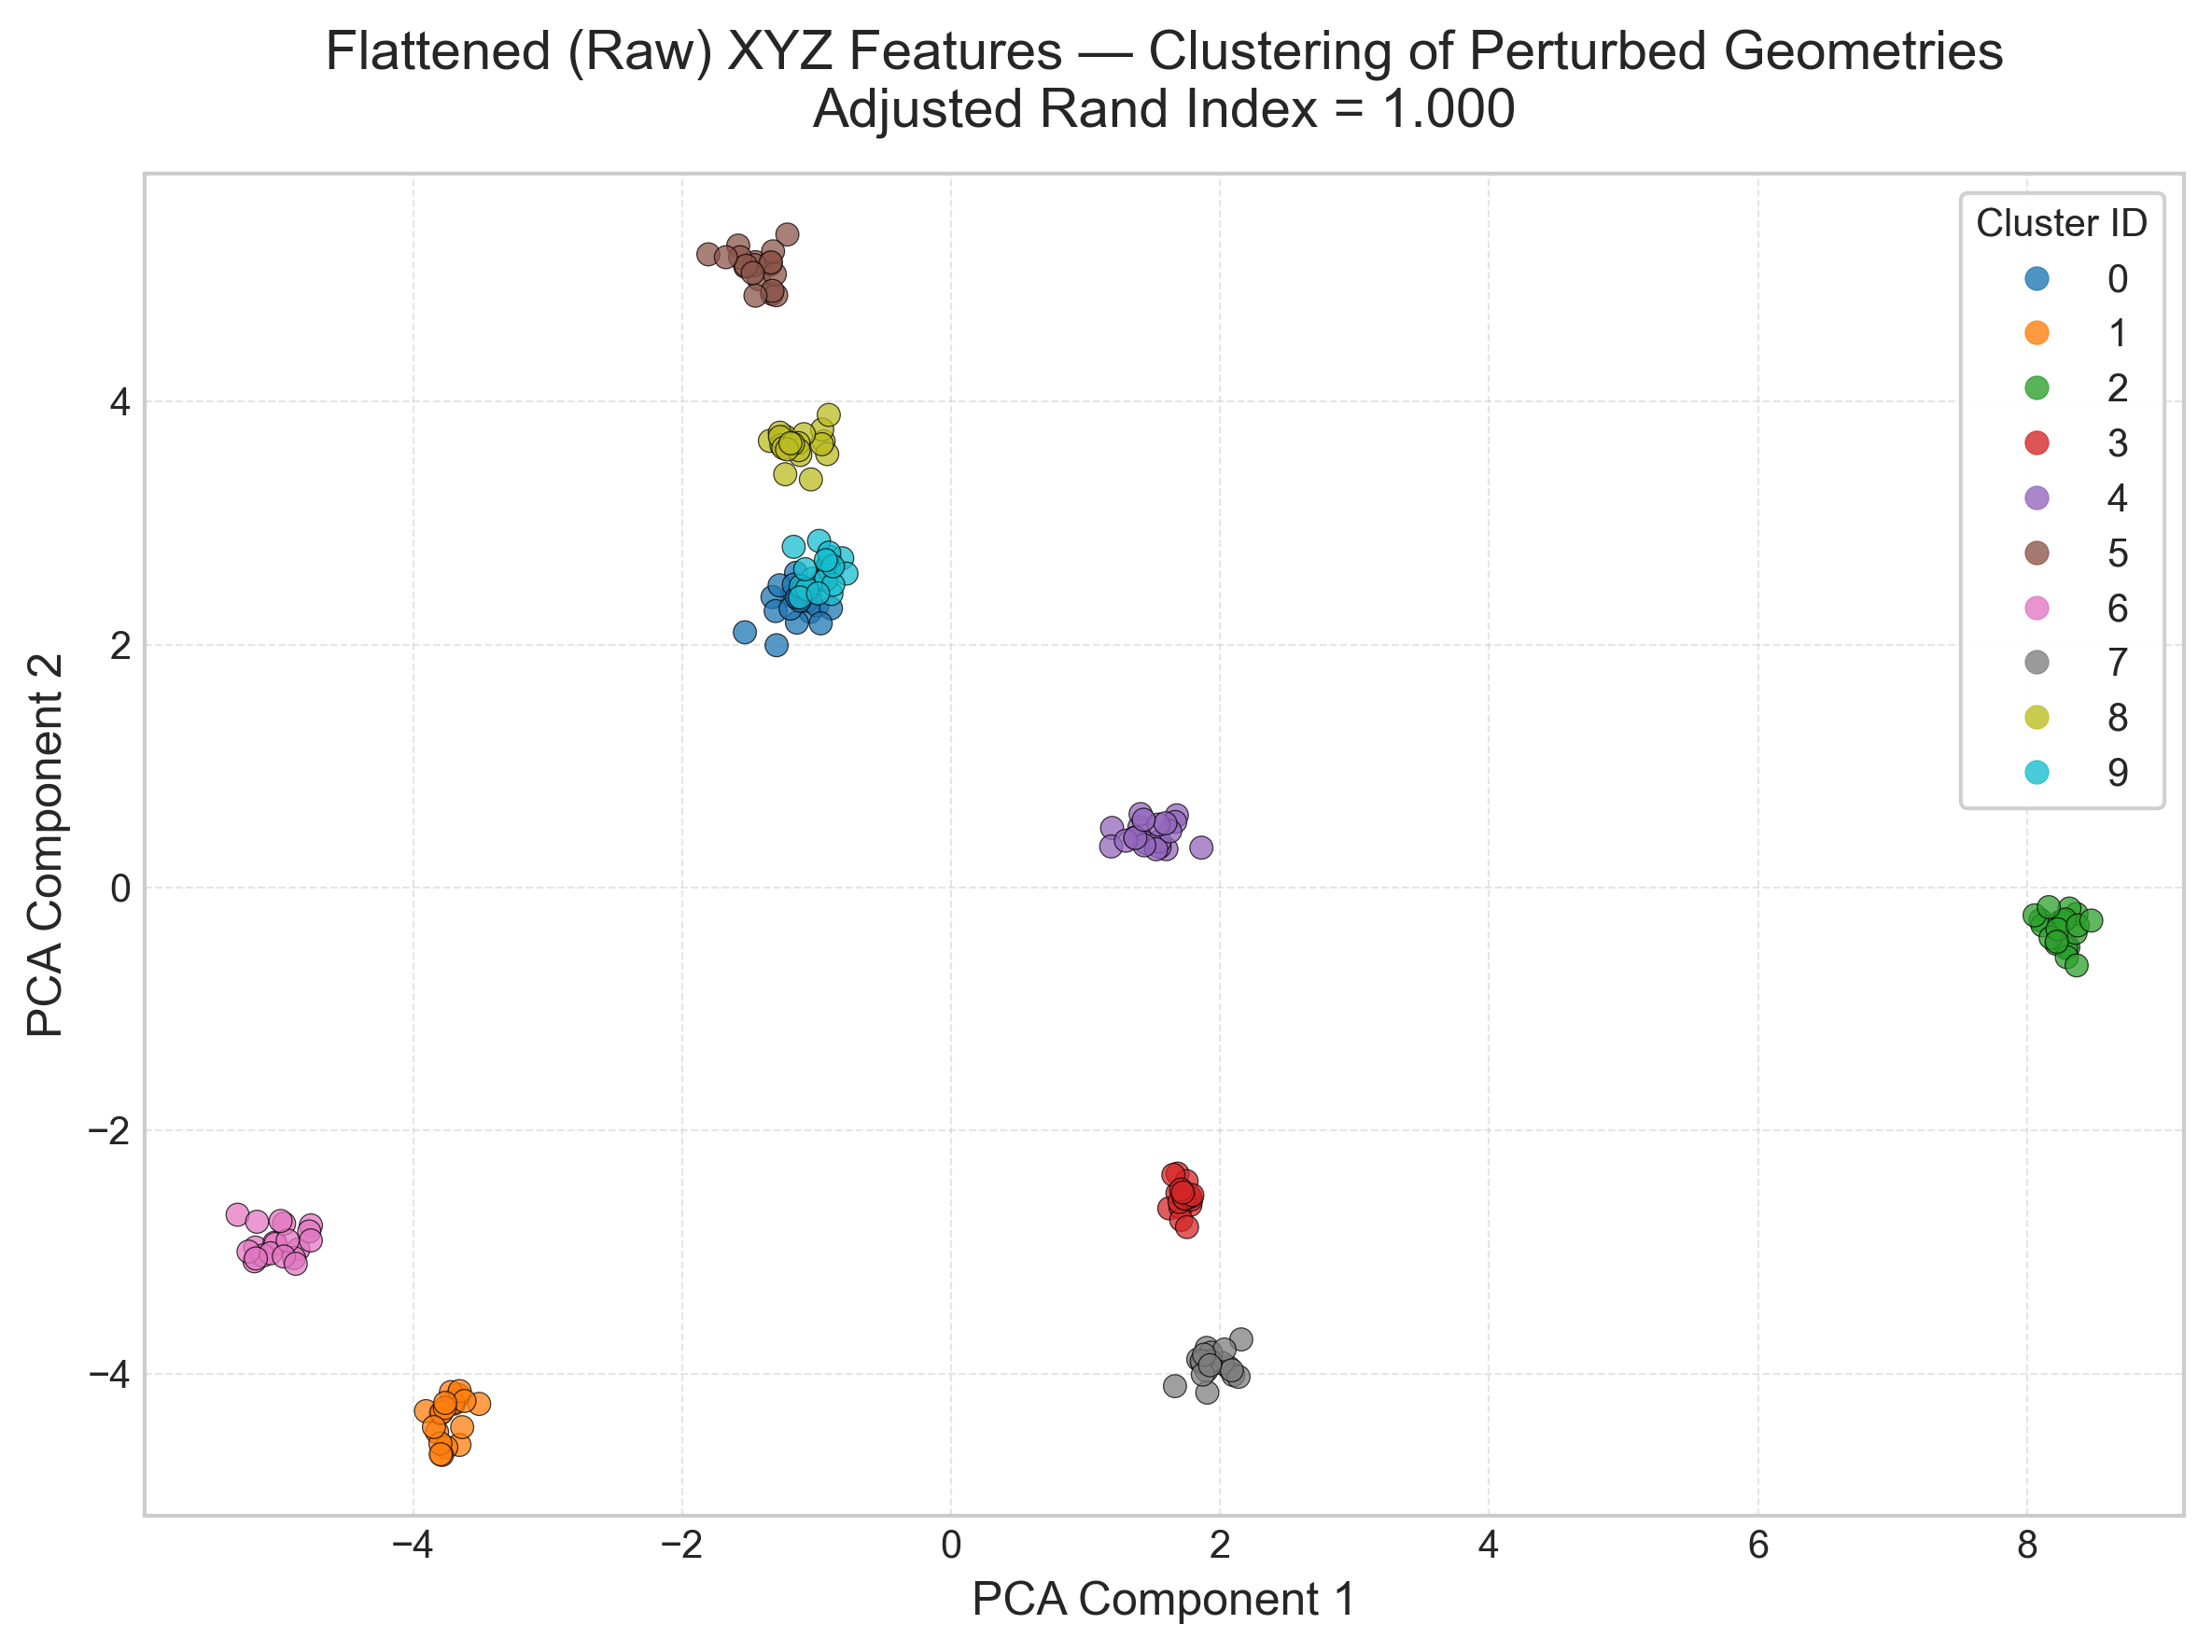

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_639""]","""[H]C1([H])O[C@]2([H])C([H])([H…",20
1,1,"[""qm9_906""]","""[H]c1nc([H])c(C([H])([H])[H])c…",20
2,1,"[""qm9_1626""]","""[H]C([H])([H])C(=O)[C@]([H])(C…",20
3,1,"[""qm9_761""]","""[H]c1noc(=O)n1[H]""",20
4,1,"[""qm9_1874""]","""[H]O[C@]12C([H])([H])C([H])([H…",20
5,1,"[""qm9_795""]","""[H]O/N=C(/C([H])([H])O[H])C([H…",20
6,1,"[""qm9_1026""]","""[H]c1nc(OC([H])([H])[H])oc1[H]""",20
7,1,"[""qm9_779""]","""[H]O/N=C(\C([H])([H])[H])C([H]…",20
8,1,"[""qm9_967""]","""[H]c1oc([H])c(N([H])[H])c1N([H…",20


In [25]:
make_clustering(frames, processed=False)